In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, f1_score, calinski_harabasz_score, davies_bouldin_score
from catboost import CatBoostClassifier

In [2]:
data = pd.read_csv("ЛР4 - Кластеризация - Вариант 1.csv")
data.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [3]:
data["Date"].unique()

array(['2023-06-04', '2023-06-11', '2023-06-18', '2023-06-25',
       '2023-07-02', '2023-07-09', '2023-07-16', '2023-07-23',
       '2023-07-30', '2023-08-06', '2023-08-13', '2023-08-20',
       '2023-08-27', '2023-09-03', '2023-09-10', '2023-09-17',
       '2023-09-24', '2023-10-01', '2023-10-08', '2023-10-15',
       '2023-10-22', '2023-10-29', '2023-11-05', '2023-11-12',
       '2023-11-19', '2023-11-26', '2023-12-03', '2023-12-10',
       '2023-12-17', '2023-12-24', '2023-12-31', '2024-01-07',
       '2024-01-14', '2024-01-21', '2024-01-28', '2024-02-04',
       '2024-02-11', '2024-02-18', '2024-02-25', '2024-03-03',
       '2024-03-10', '2024-03-17', '2024-03-24', '2024-03-31',
       '2024-04-07', '2024-04-14', '2024-04-21', '2024-04-28',
       '2024-05-05', '2024-05-12', '2024-05-19', '2024-05-26',
       '2024-06-02', '2024-06-09', '2024-06-16', '2024-06-23',
       '2024-06-30'], dtype=object)

В файле содержится журнал рейсов различных типов судов за период с июня 2023 по июнь 2024 года. Каждая строка — это запись об одном рейсе для конкретного судна.

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.describe()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
count,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000
mean,17.602863,1757.610939,1036.406203,9.929103,1032.573264,255143.344488,521362.062011,41.747536,0.798656,1.003816,4.914839,75.219222
std,4.311979,717.002777,568.632080,2.876423,558.697499,140890.482189,271211.625499,17.633130,0.403590,0.288251,2.597647,14.510168
min,10.009756,501.025220,50.433150,5.001947,50.229624,10092.306318,50351.814447,12.019909,0.100211,0.500004,1.000000,50.012005
25%,13.928452,1148.104914,548.511573,7.437485,553.983629,131293.378767,290346.388017,26.173537,0.463592,0.758033,3.000000,62.703724
50%,17.713757,1757.494344,1037.816060,9.918965,1043.207497,257157.653226,520176.931762,41.585188,0.789877,1.009009,5.000000,75.504709
75%,21.284785,2382.594292,1540.934161,12.413149,1527.722391,381796.930499,750072.791216,57.363922,1.147426,1.252808,7.000000,87.721205
max,24.997043,2998.734329,1998.337057,14.992947,1999.126697,499734.867868,999916.696140,71.972415,1.499259,1.499224,9.000000,99.999643


In [6]:
def delete_outliers(df_r, column):
    df = df_r.copy()
    fig,axes = plt.subplots(1,2, figsize = (30, 10))
    axes[0].boxplot(df[column])
    axes[0].set_title("Ящик с усами для столбца \n" + column + " до удаления выбросов")
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    axes[1].boxplot(df[column])
    axes[1].set_title("Ящик с усами для столбца \n" + column + " после удаления выбросов")
    return df


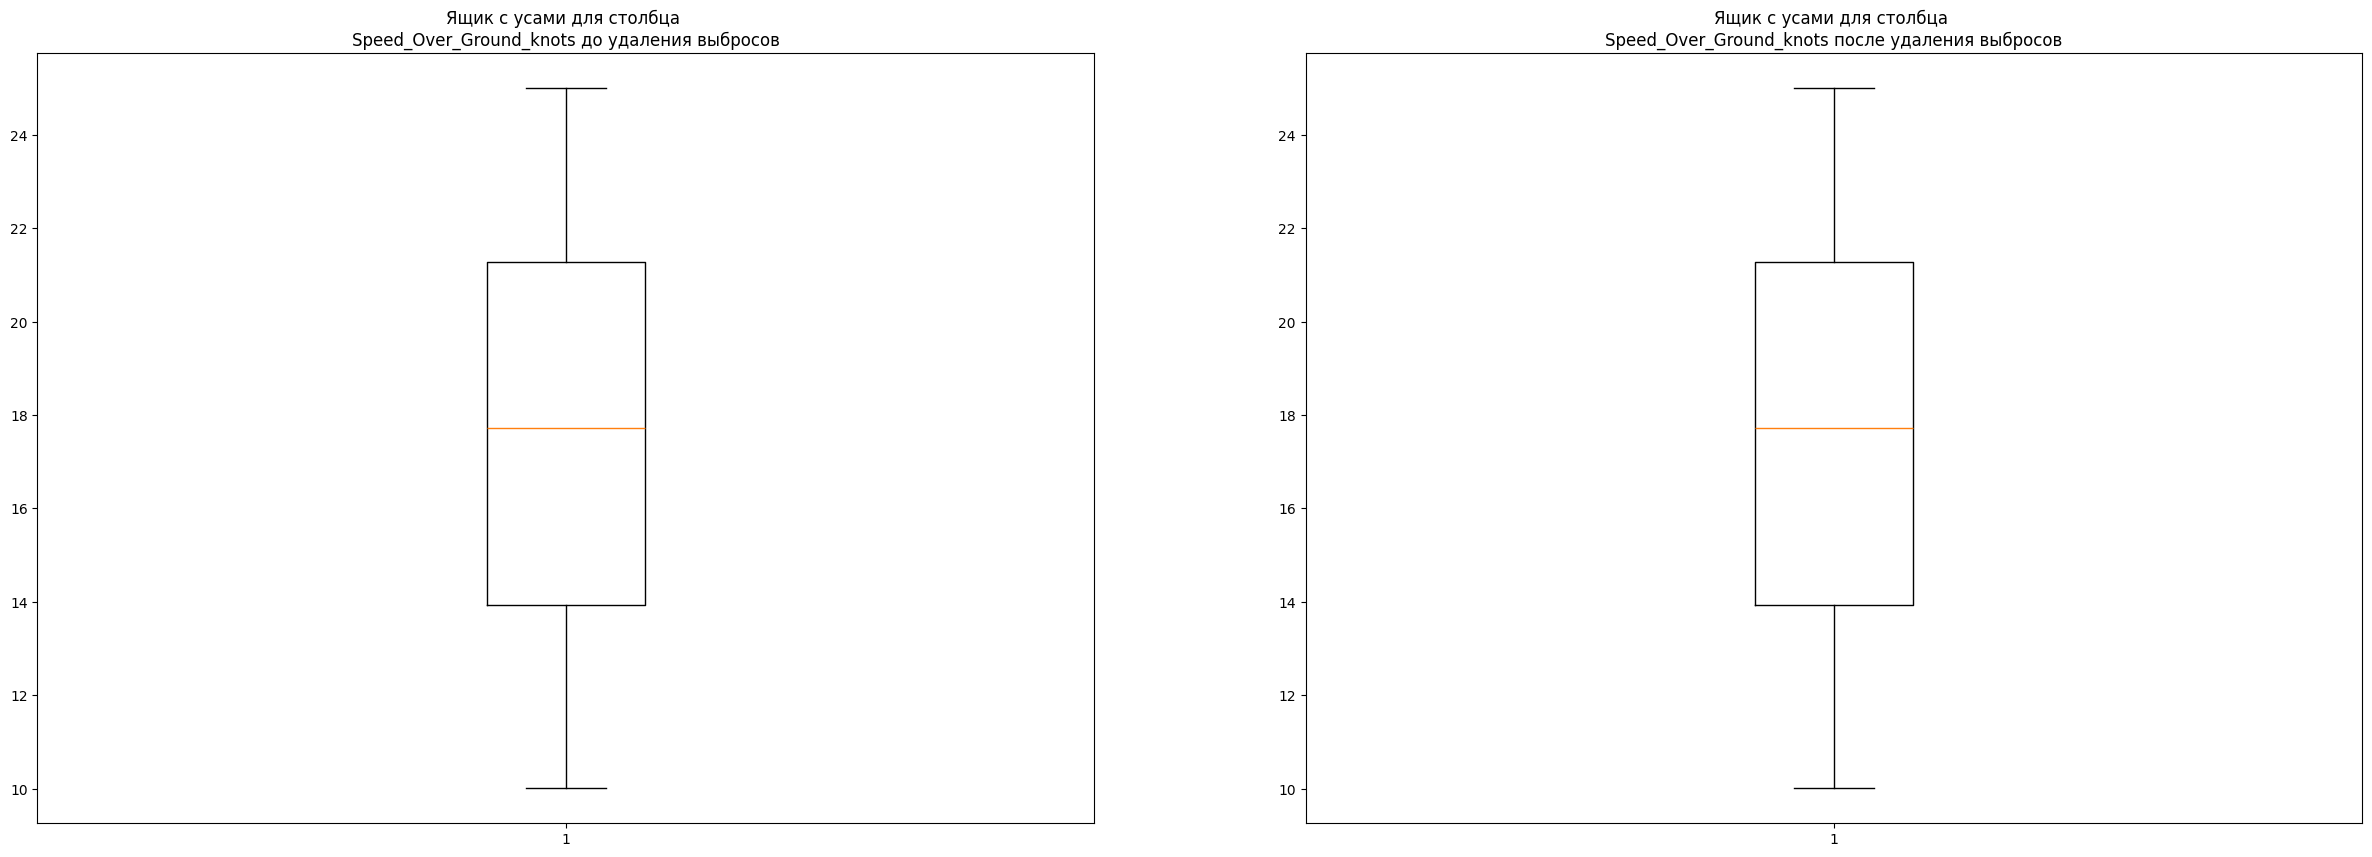

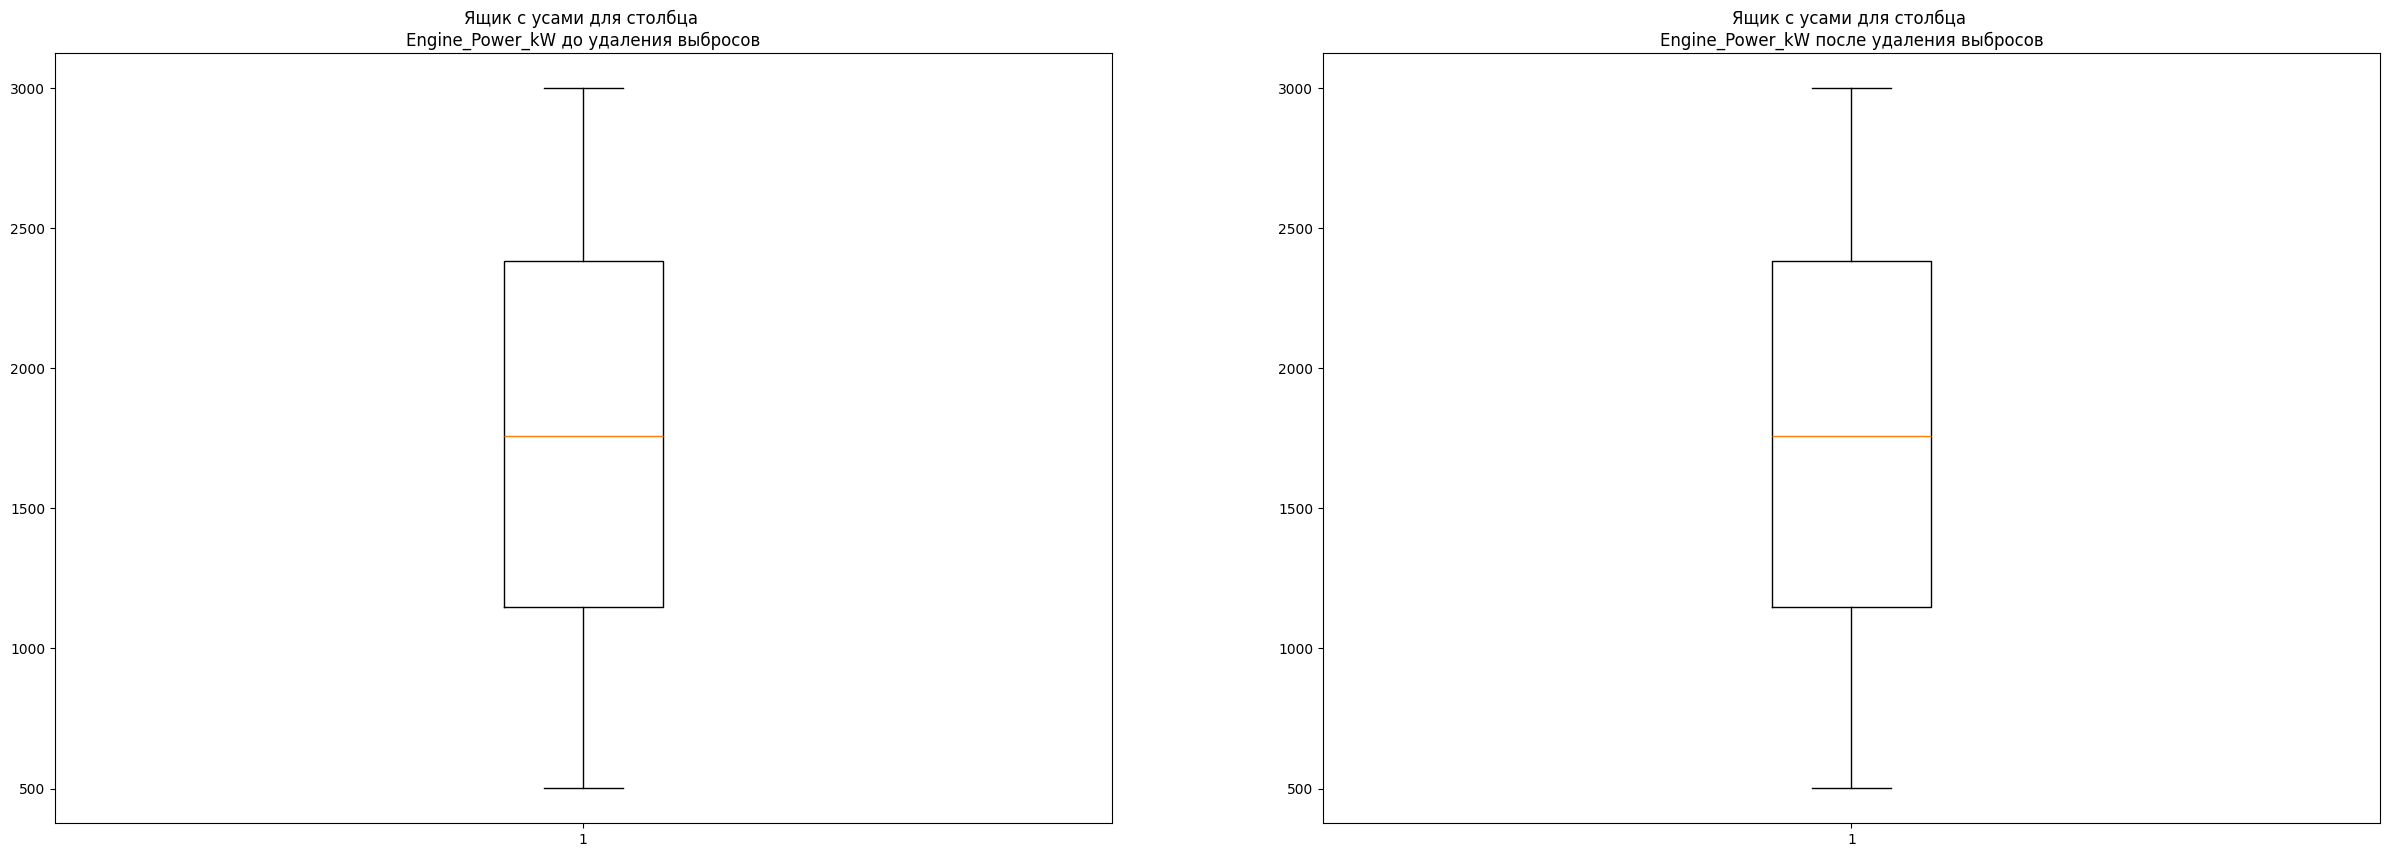

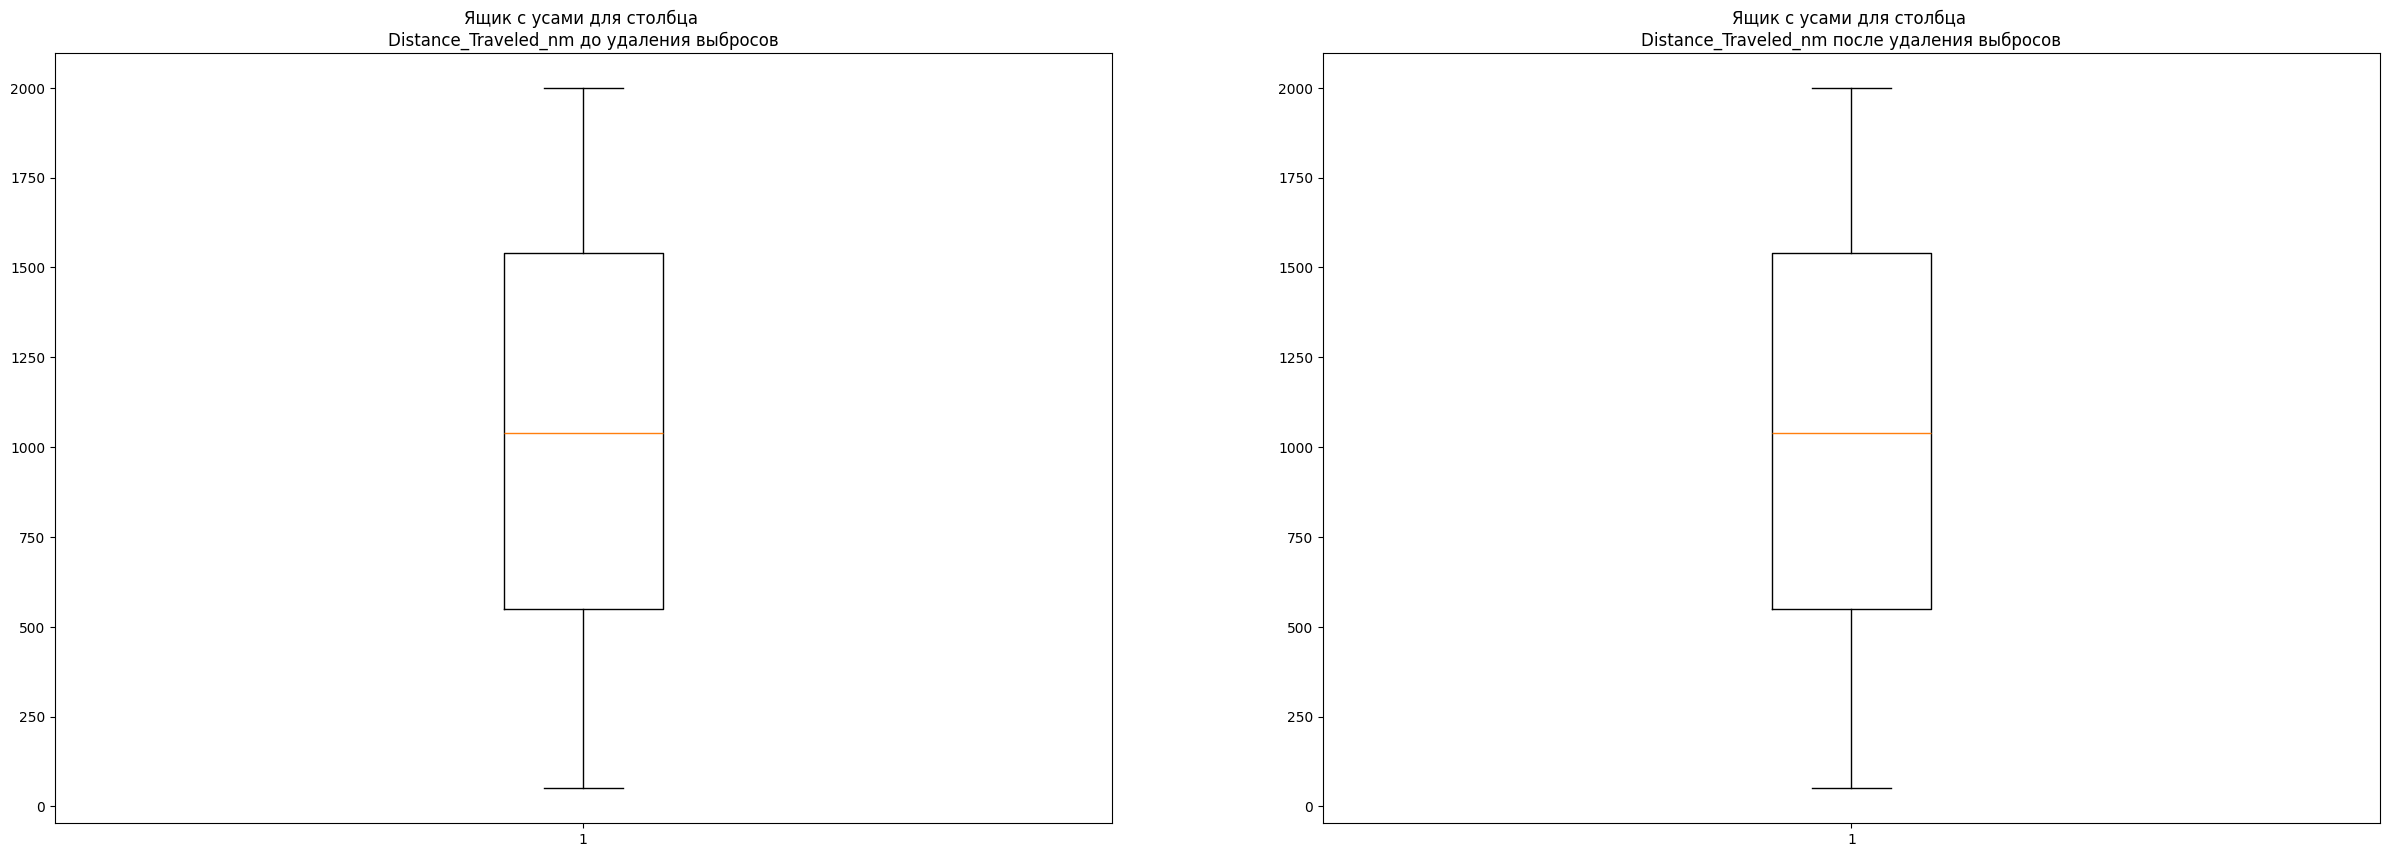

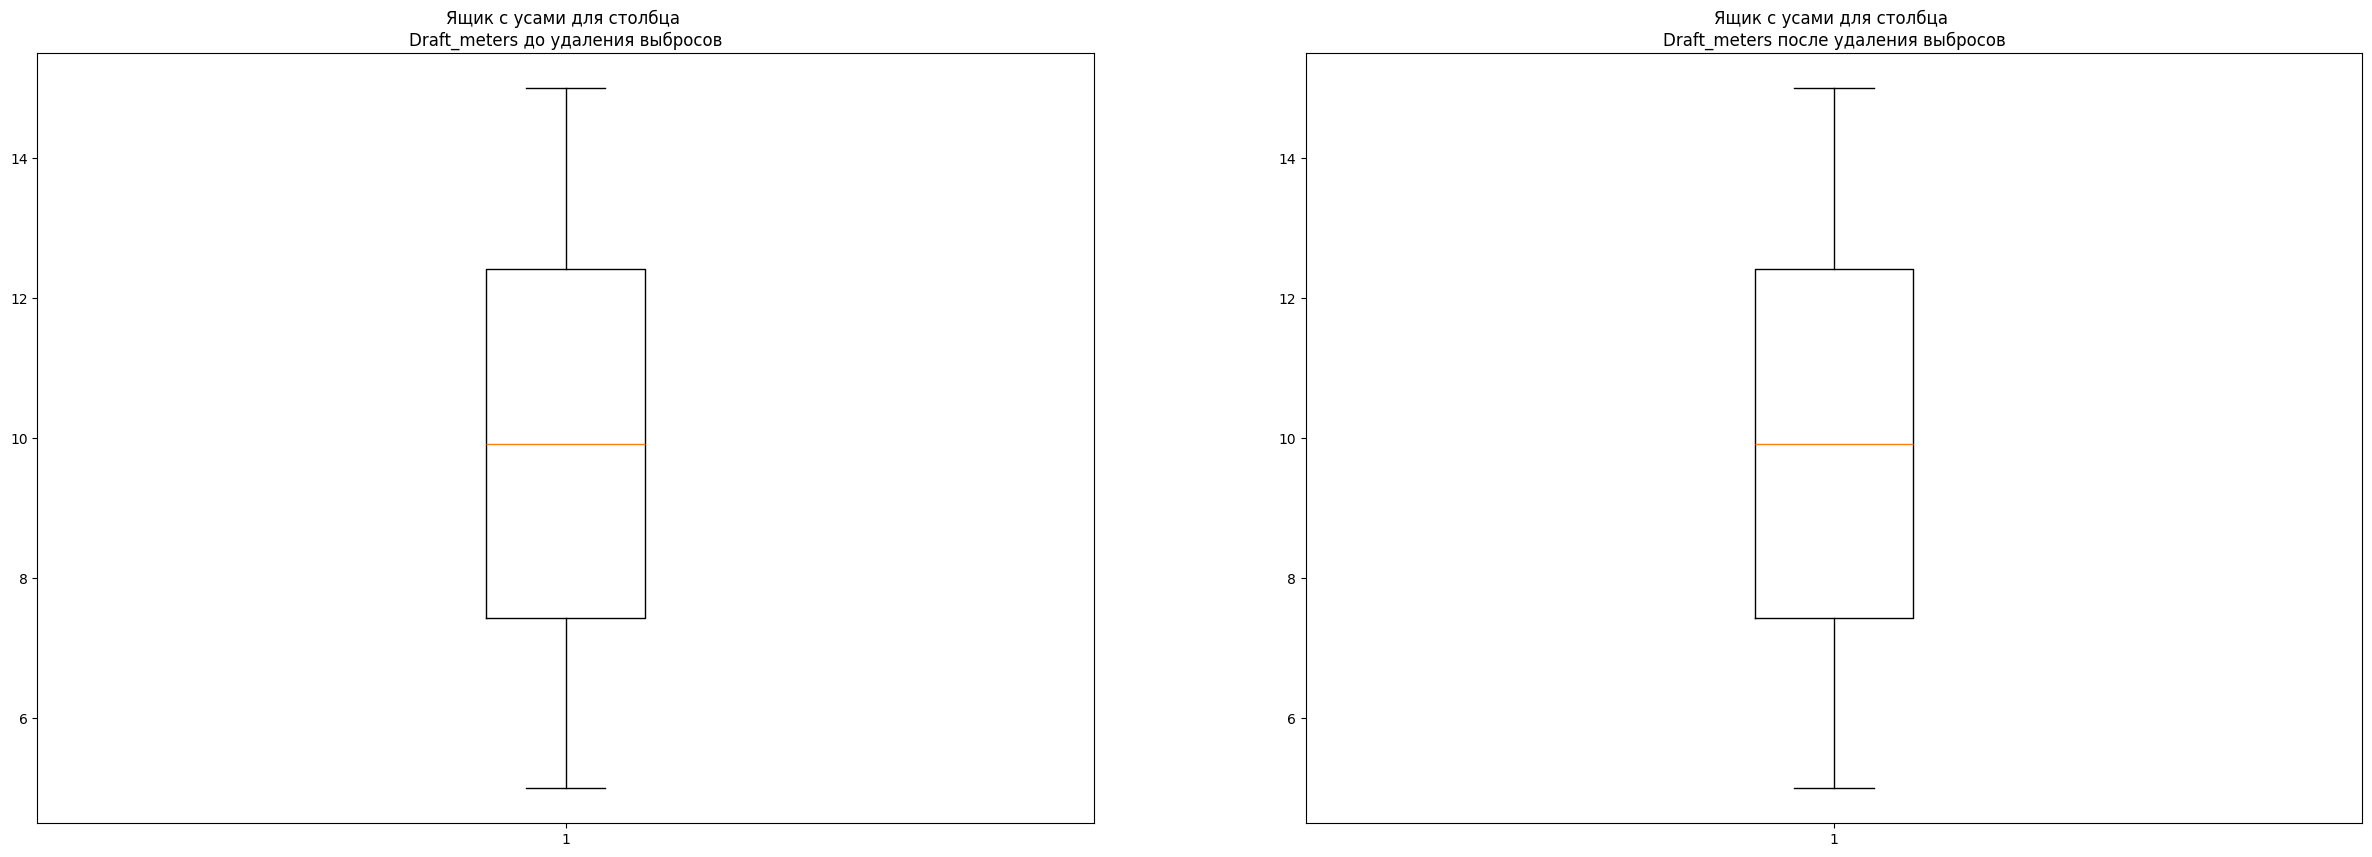

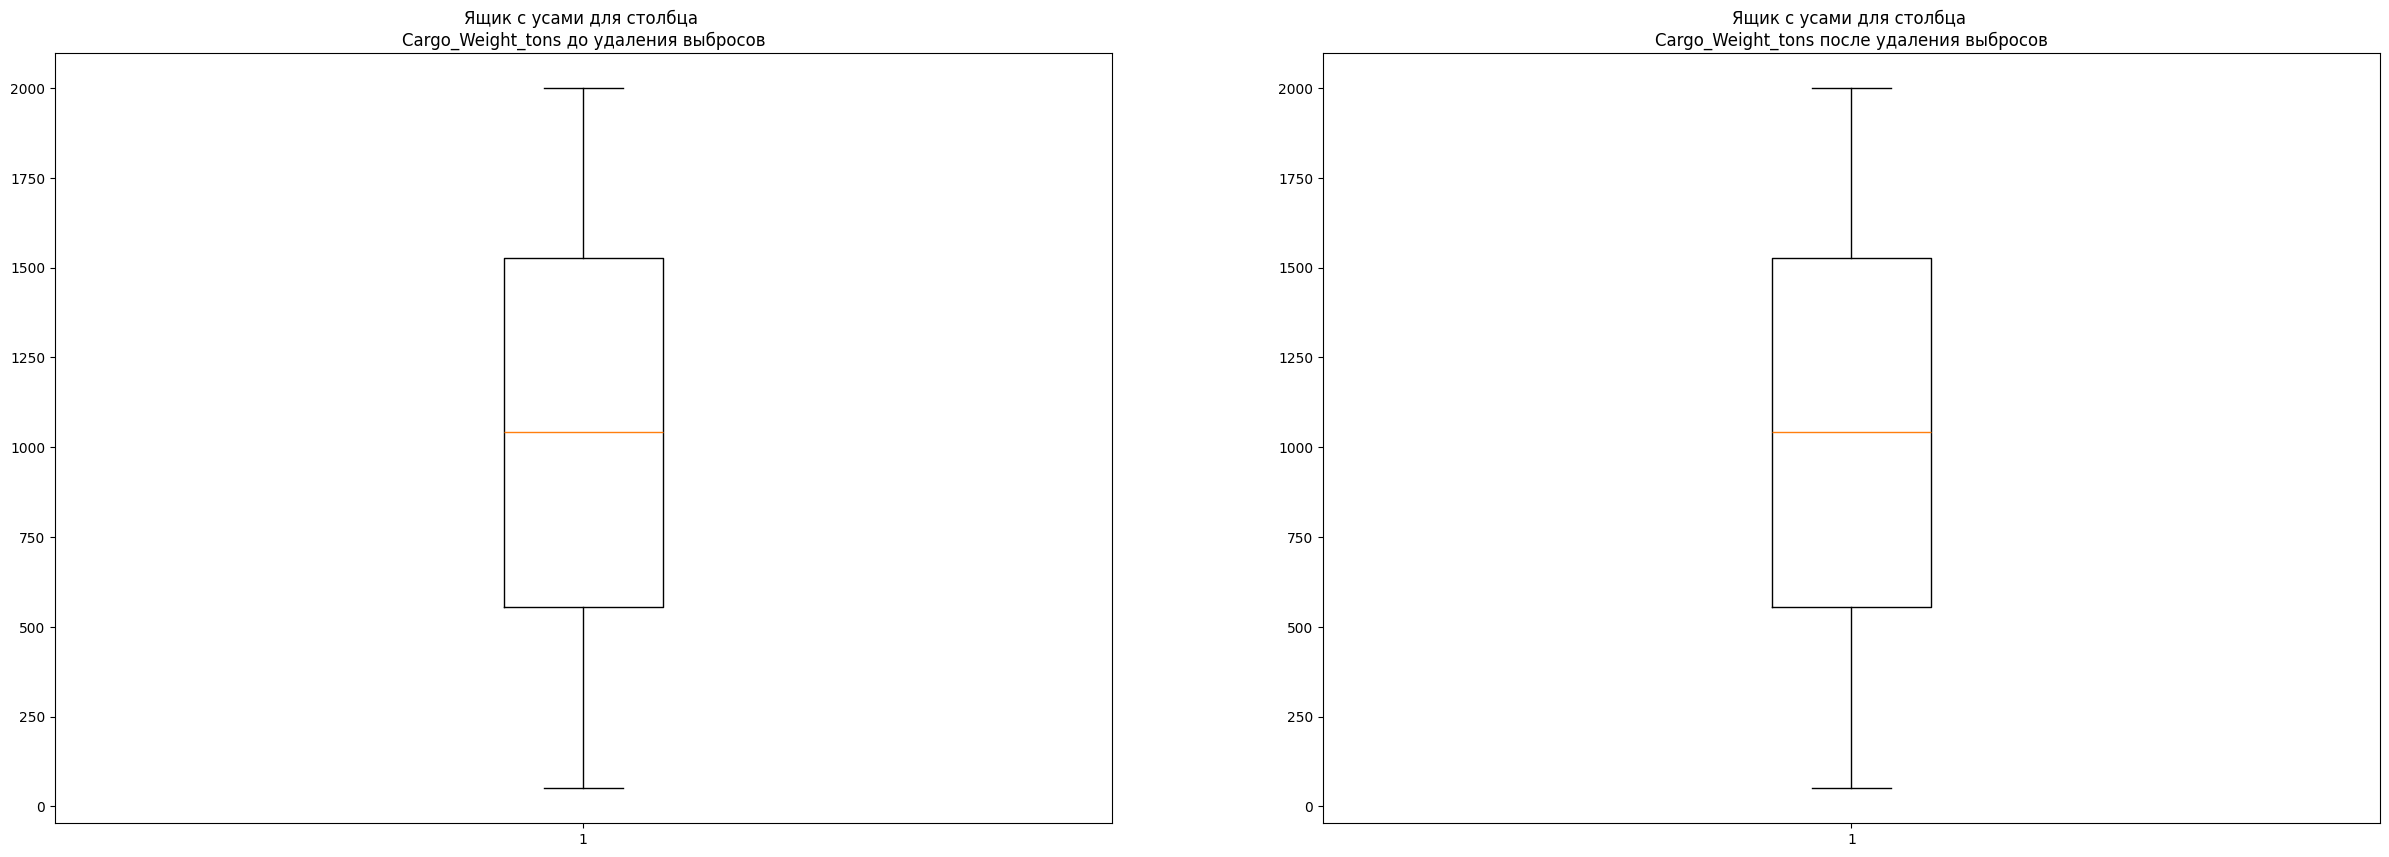

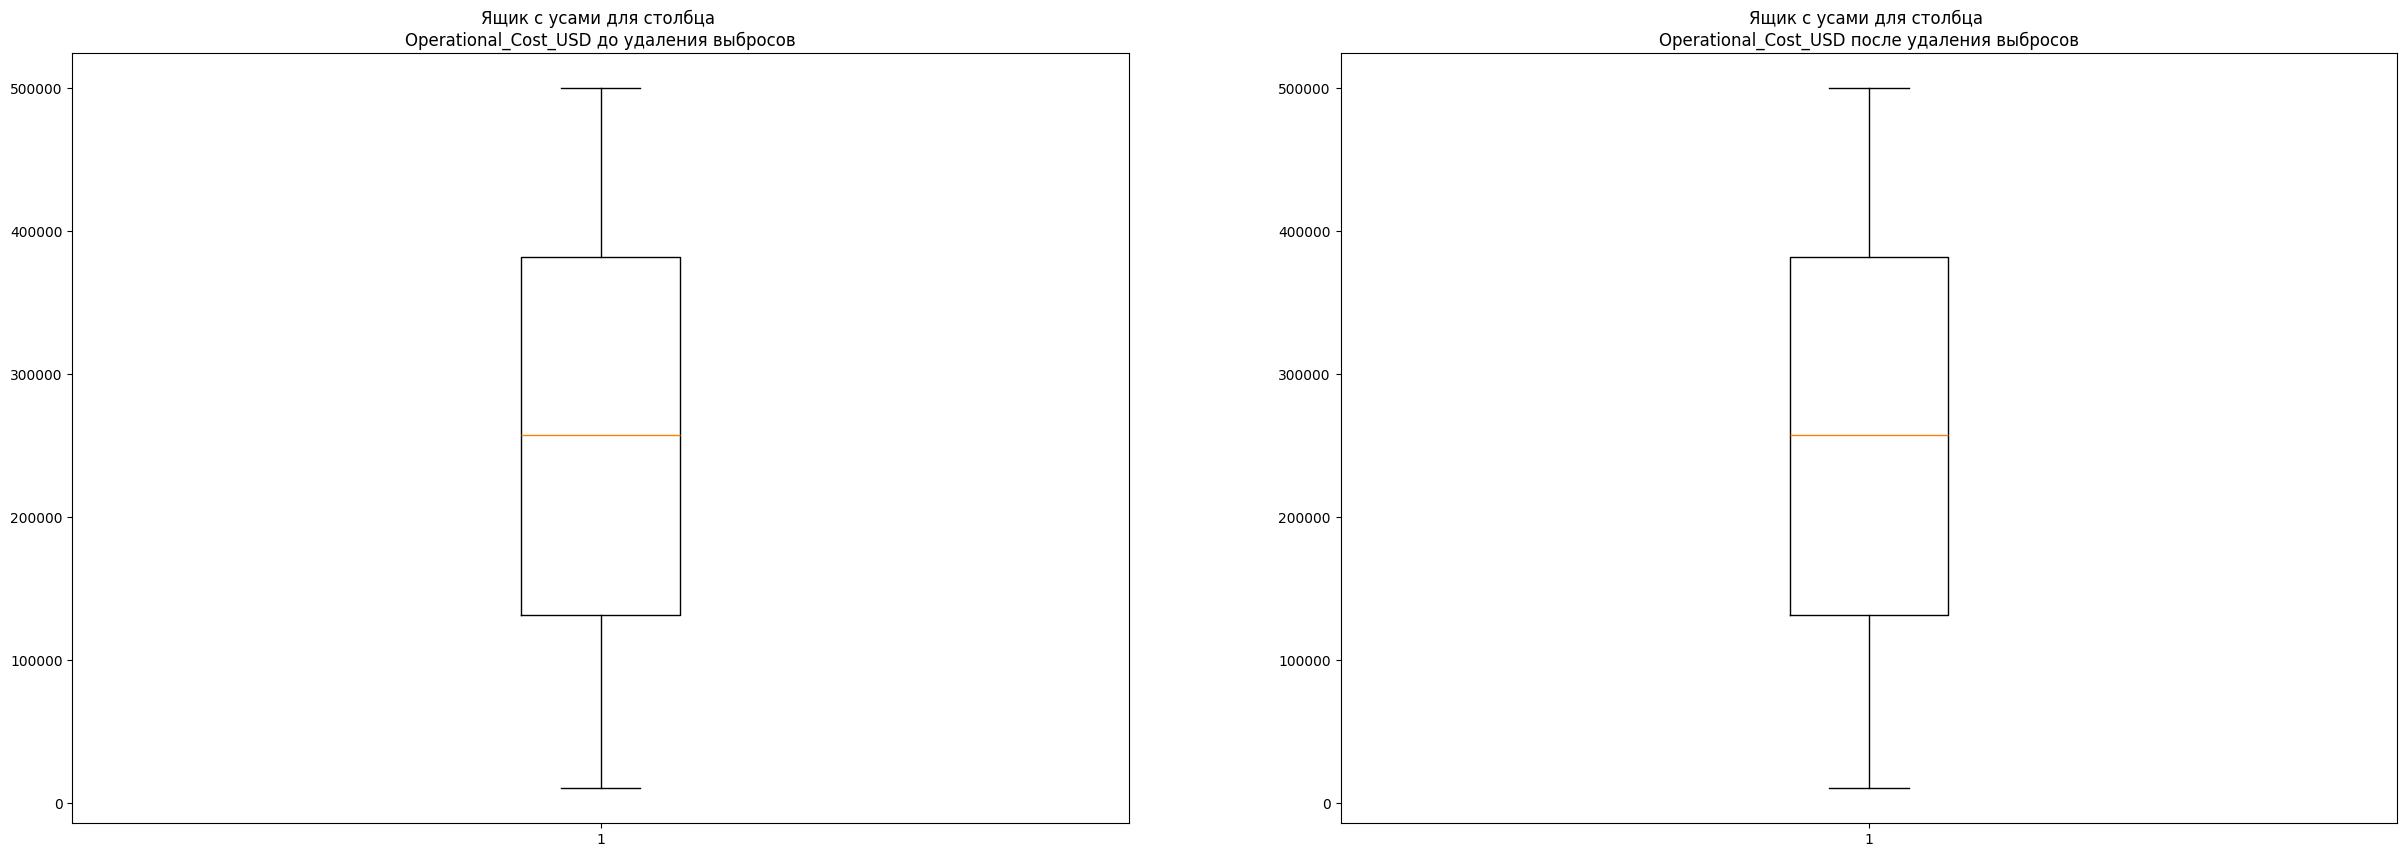

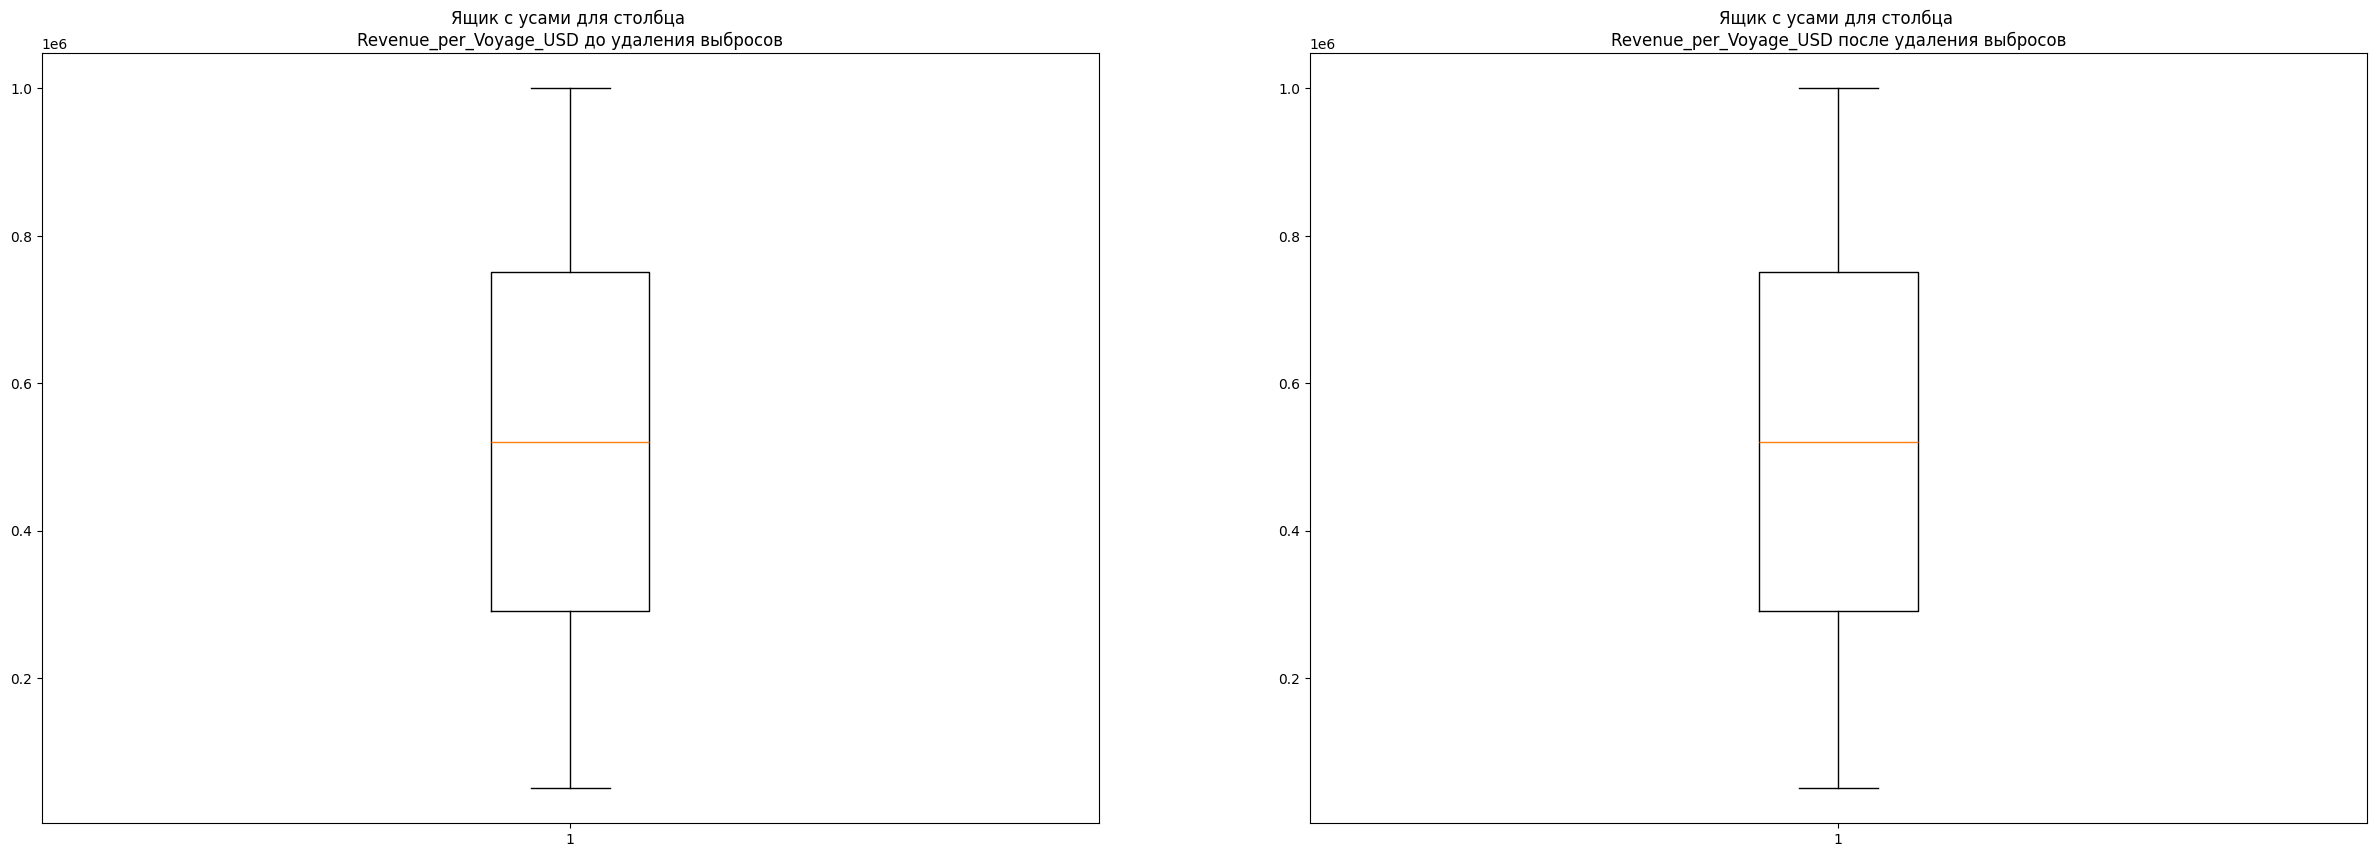

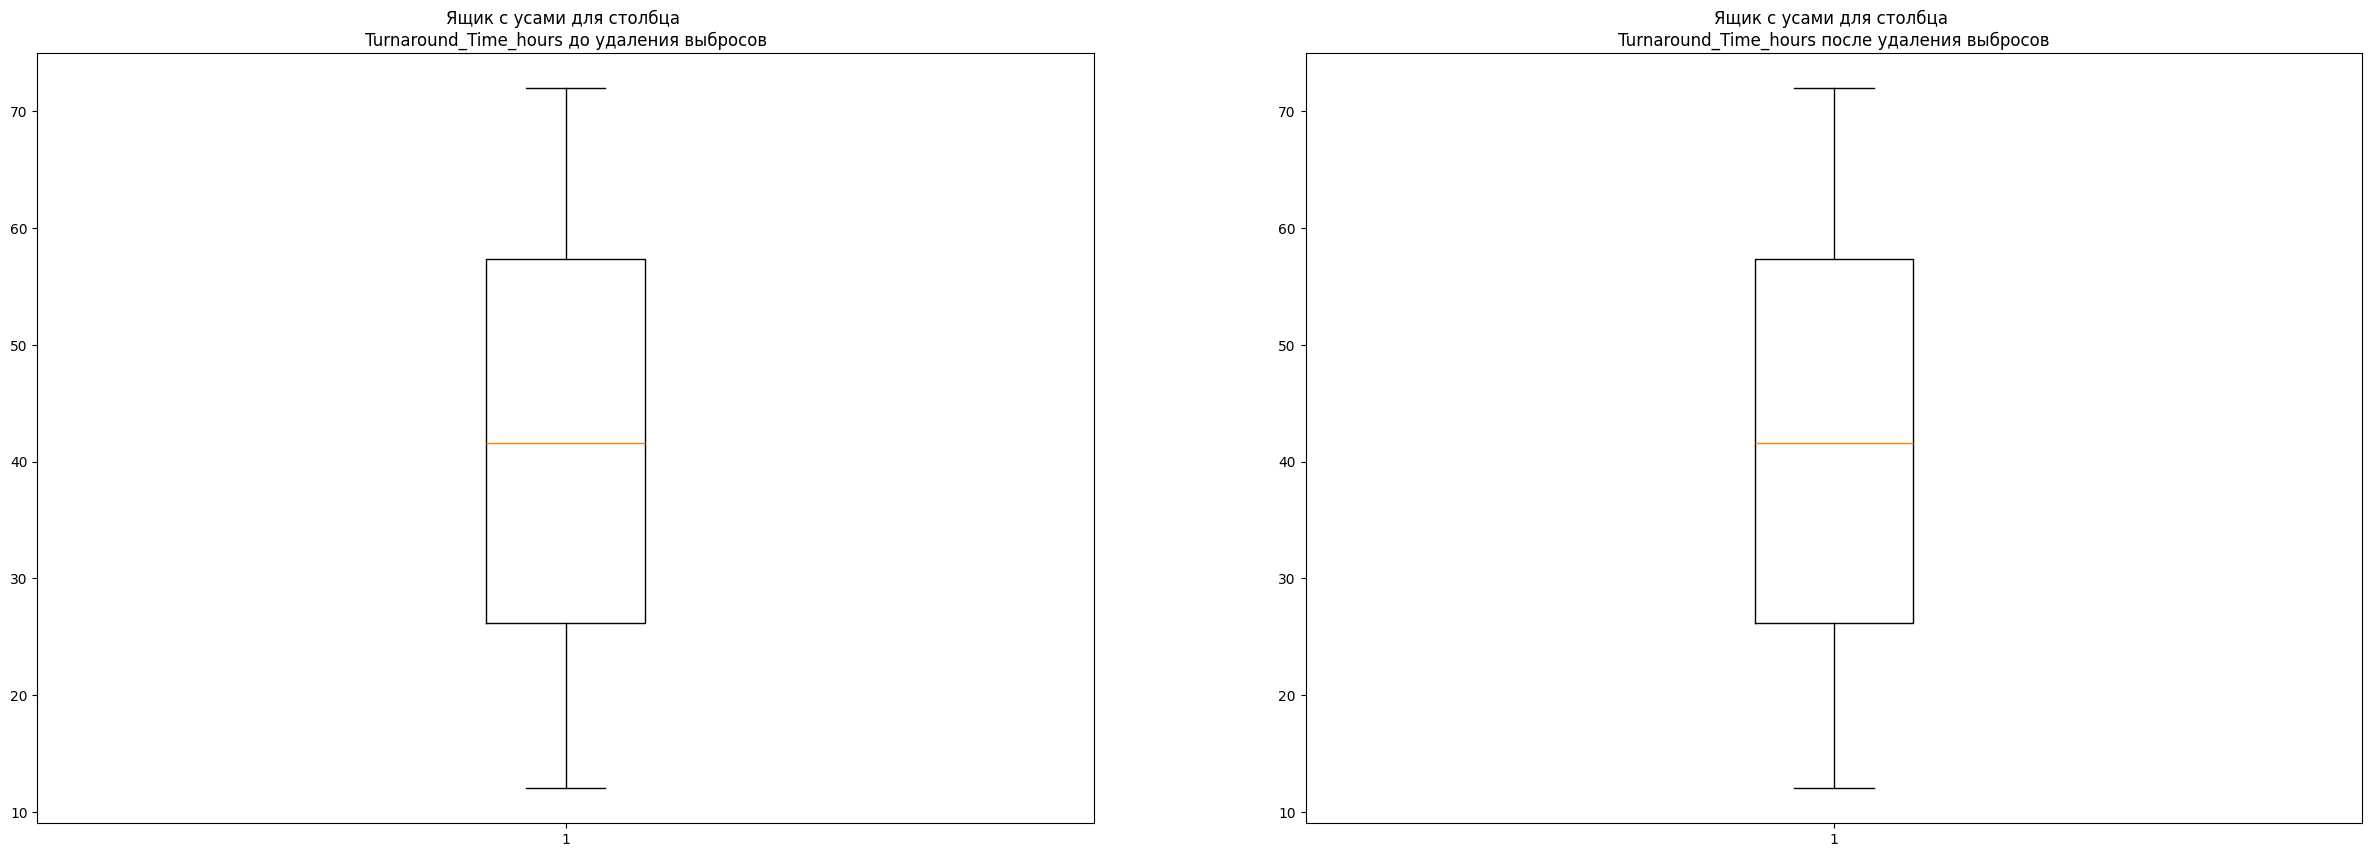

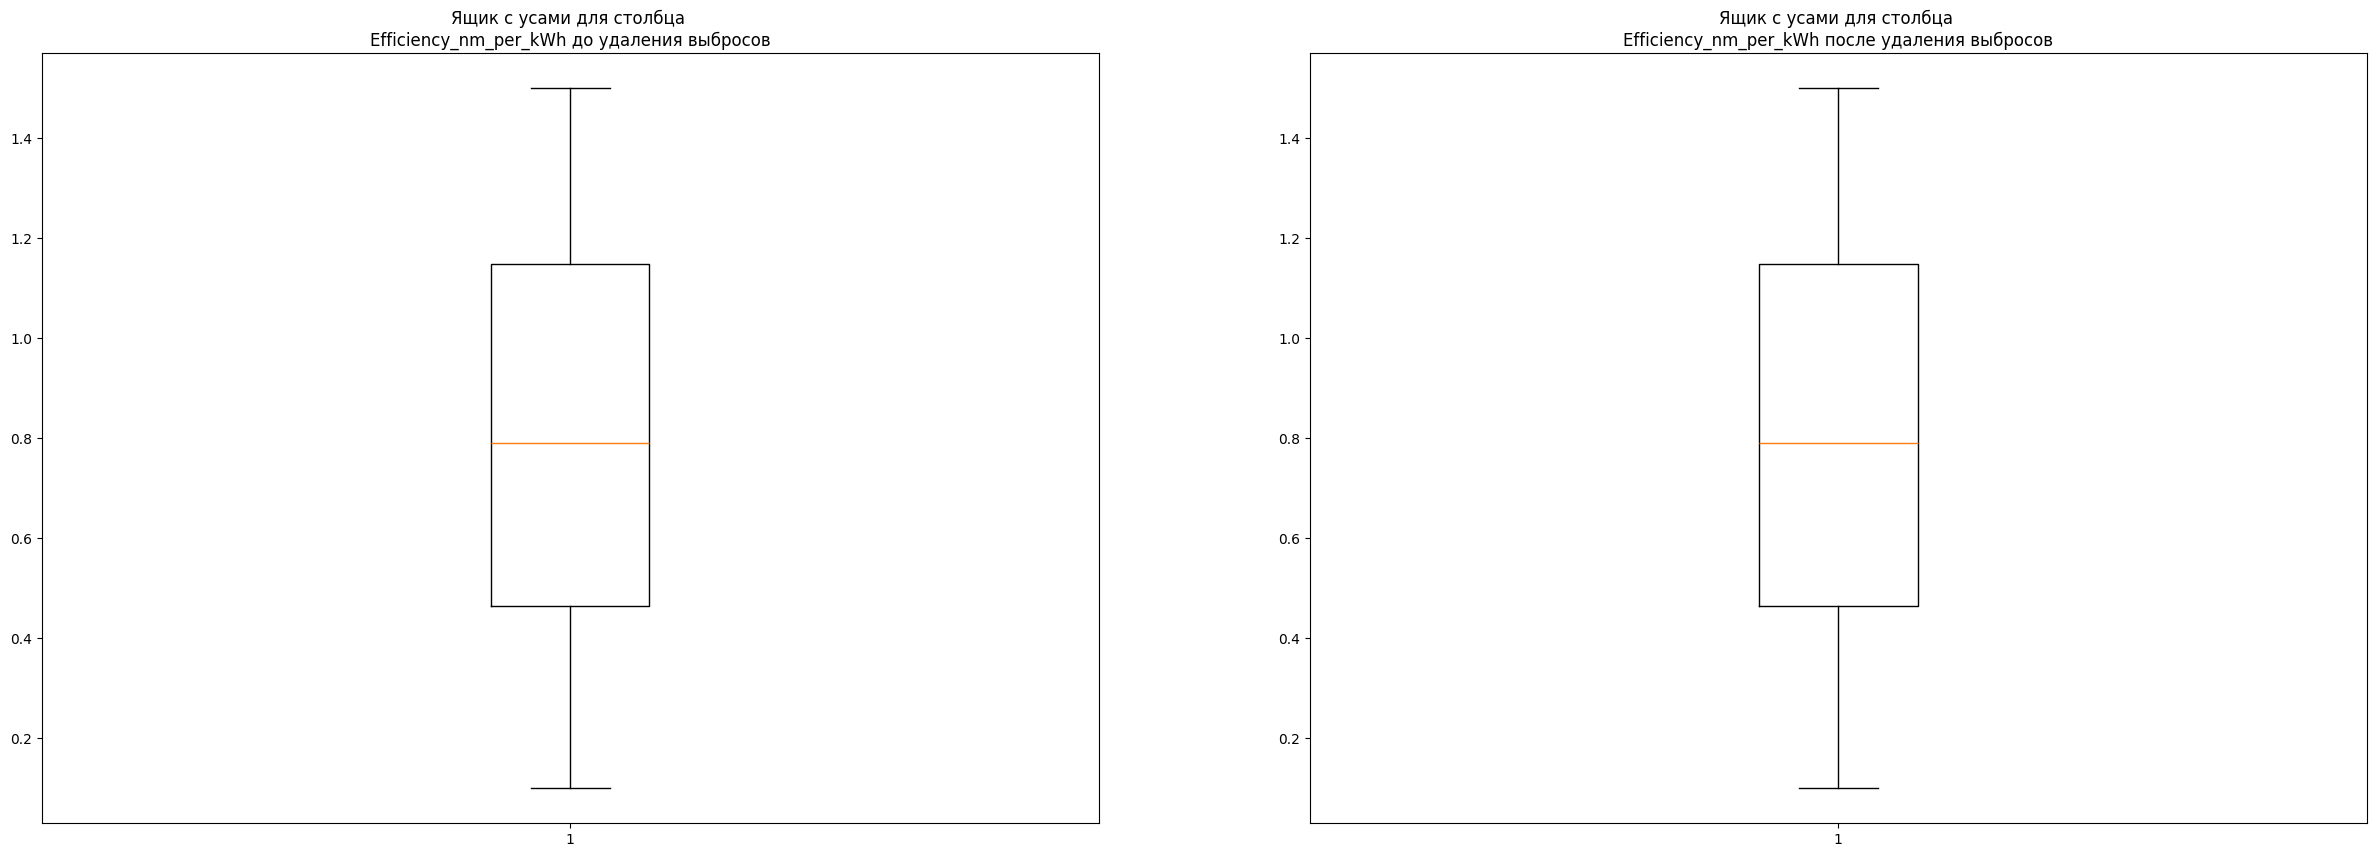

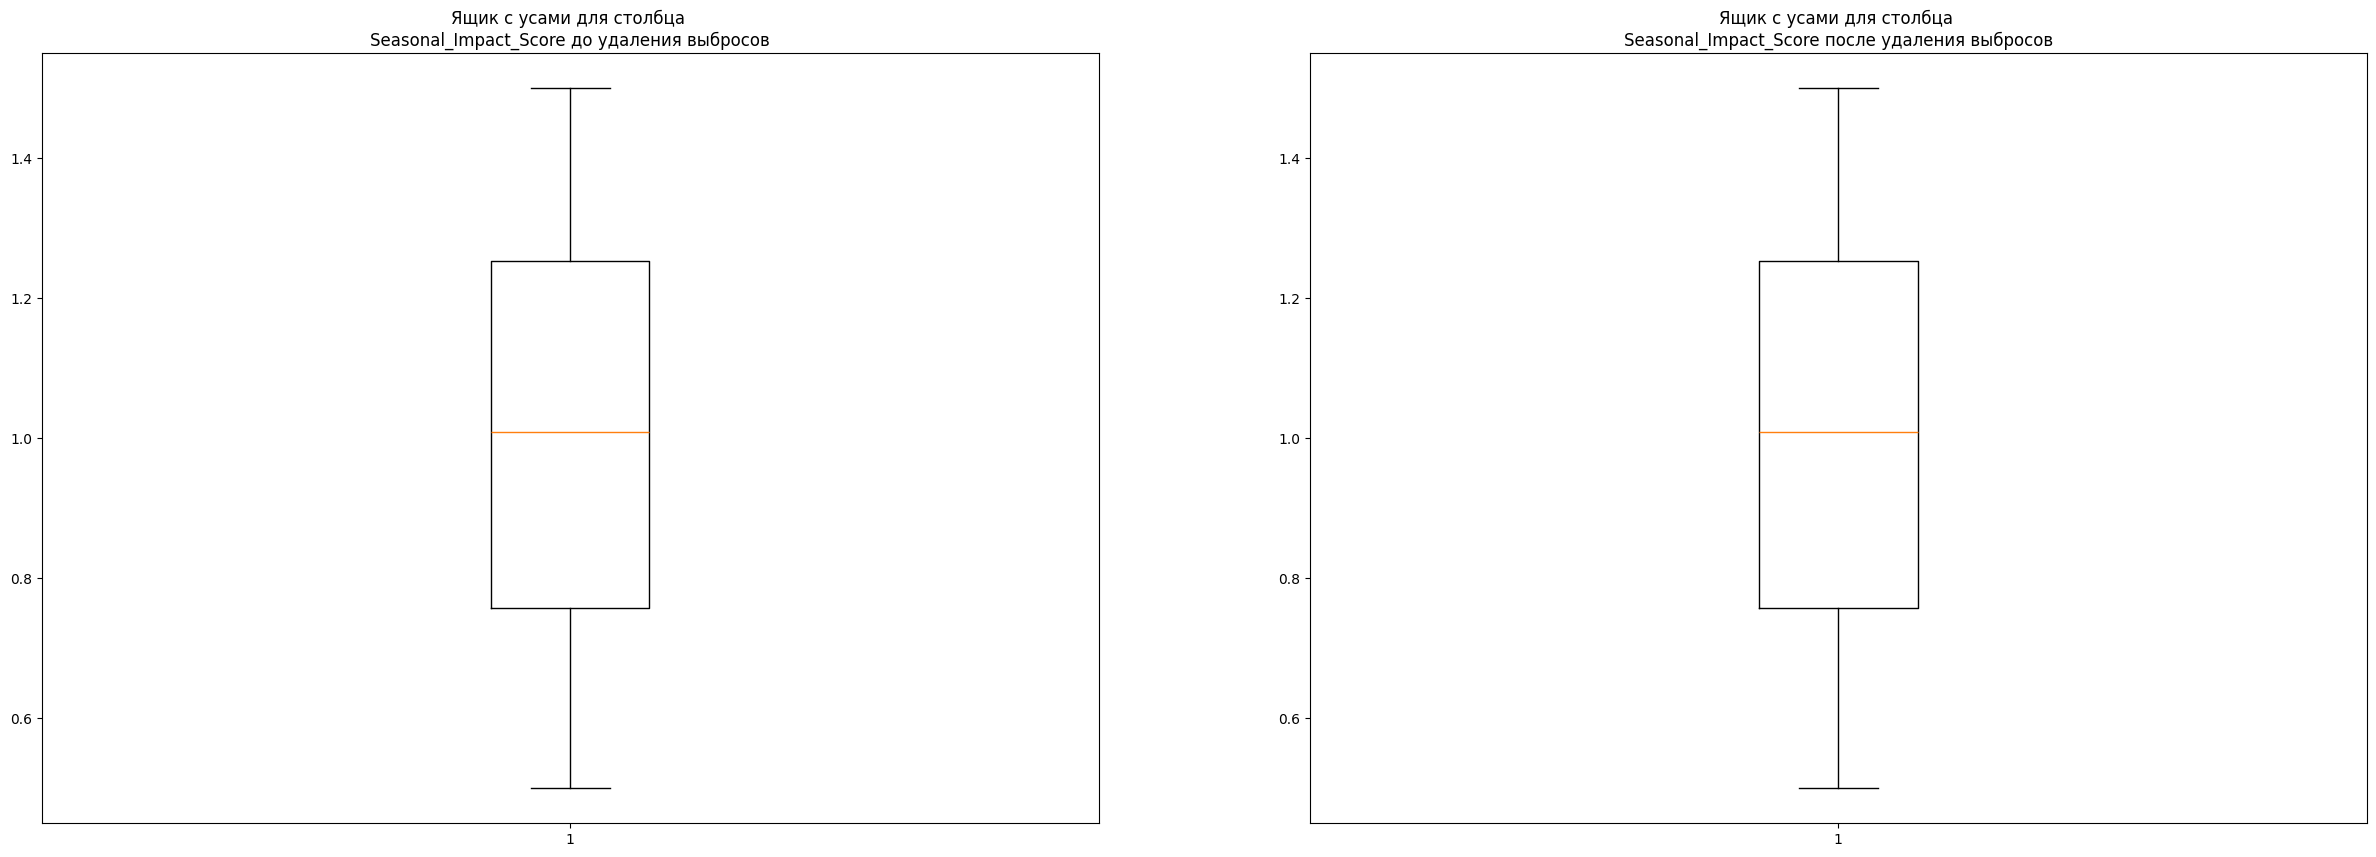

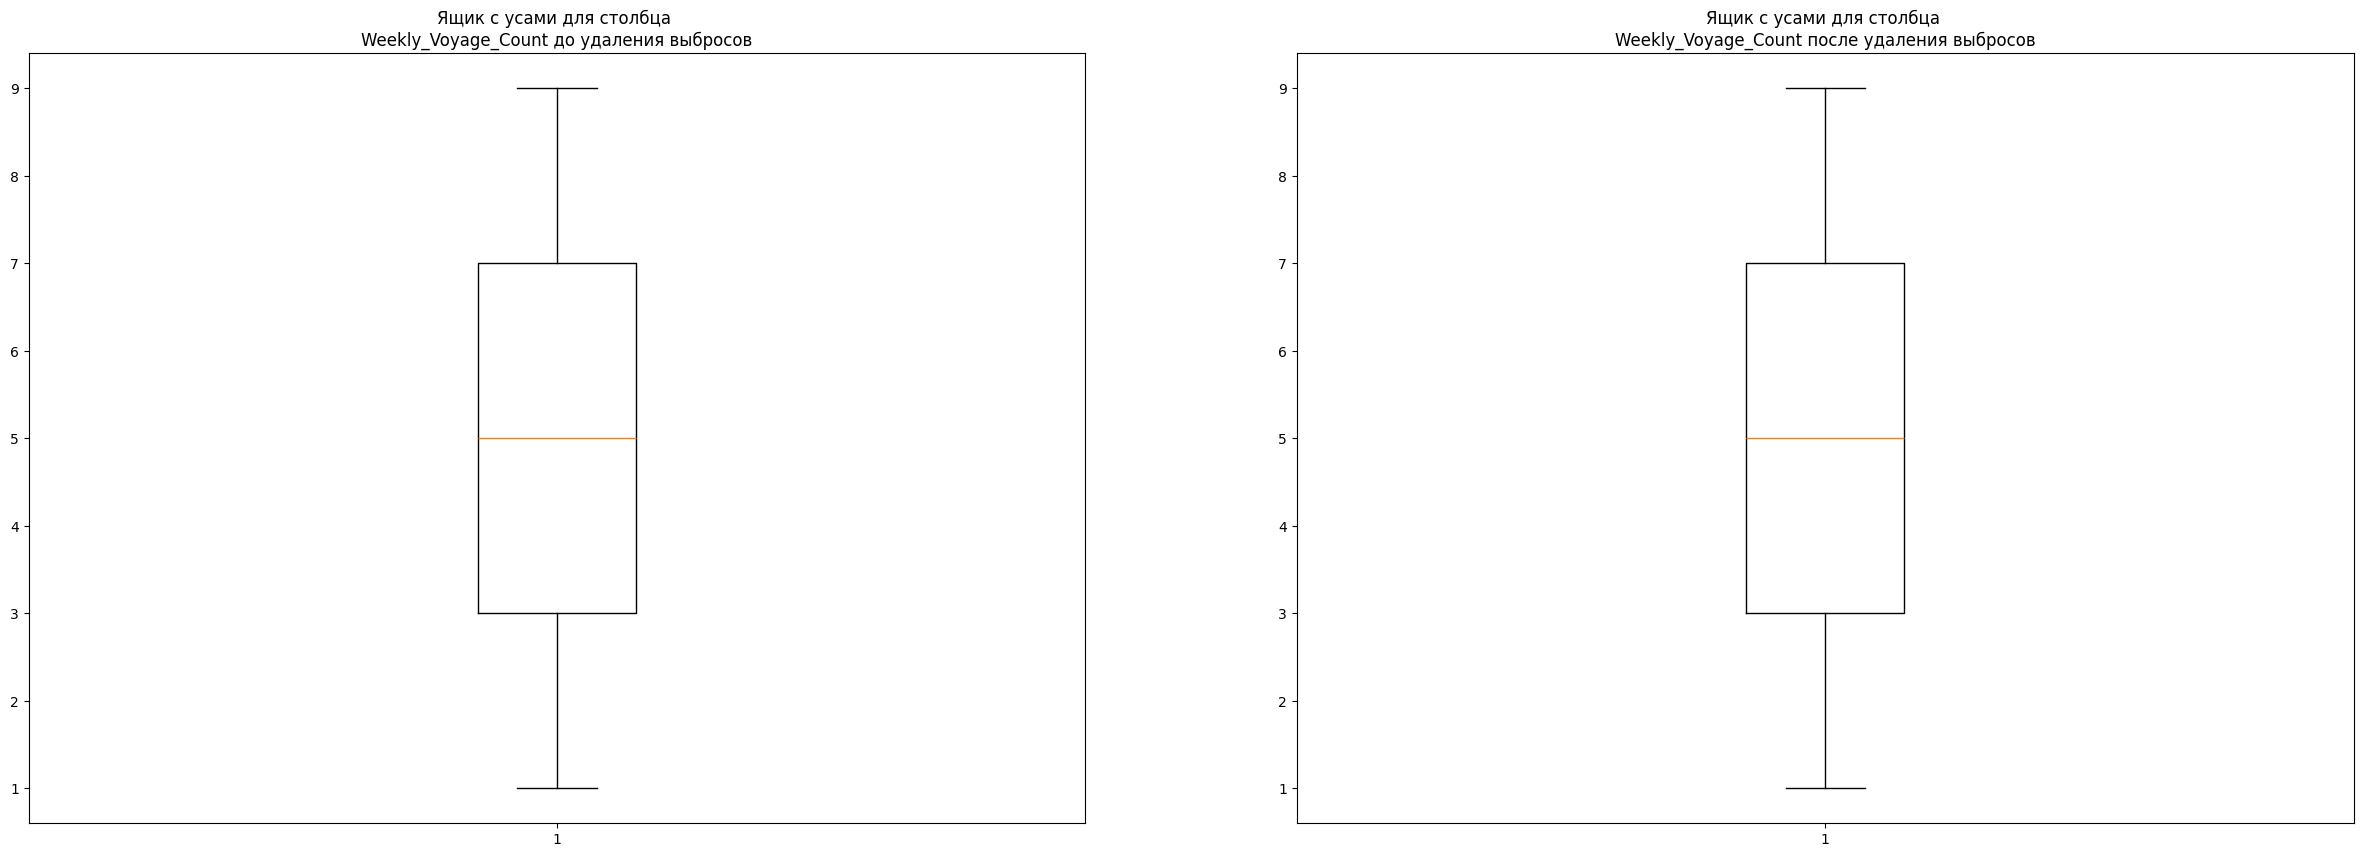

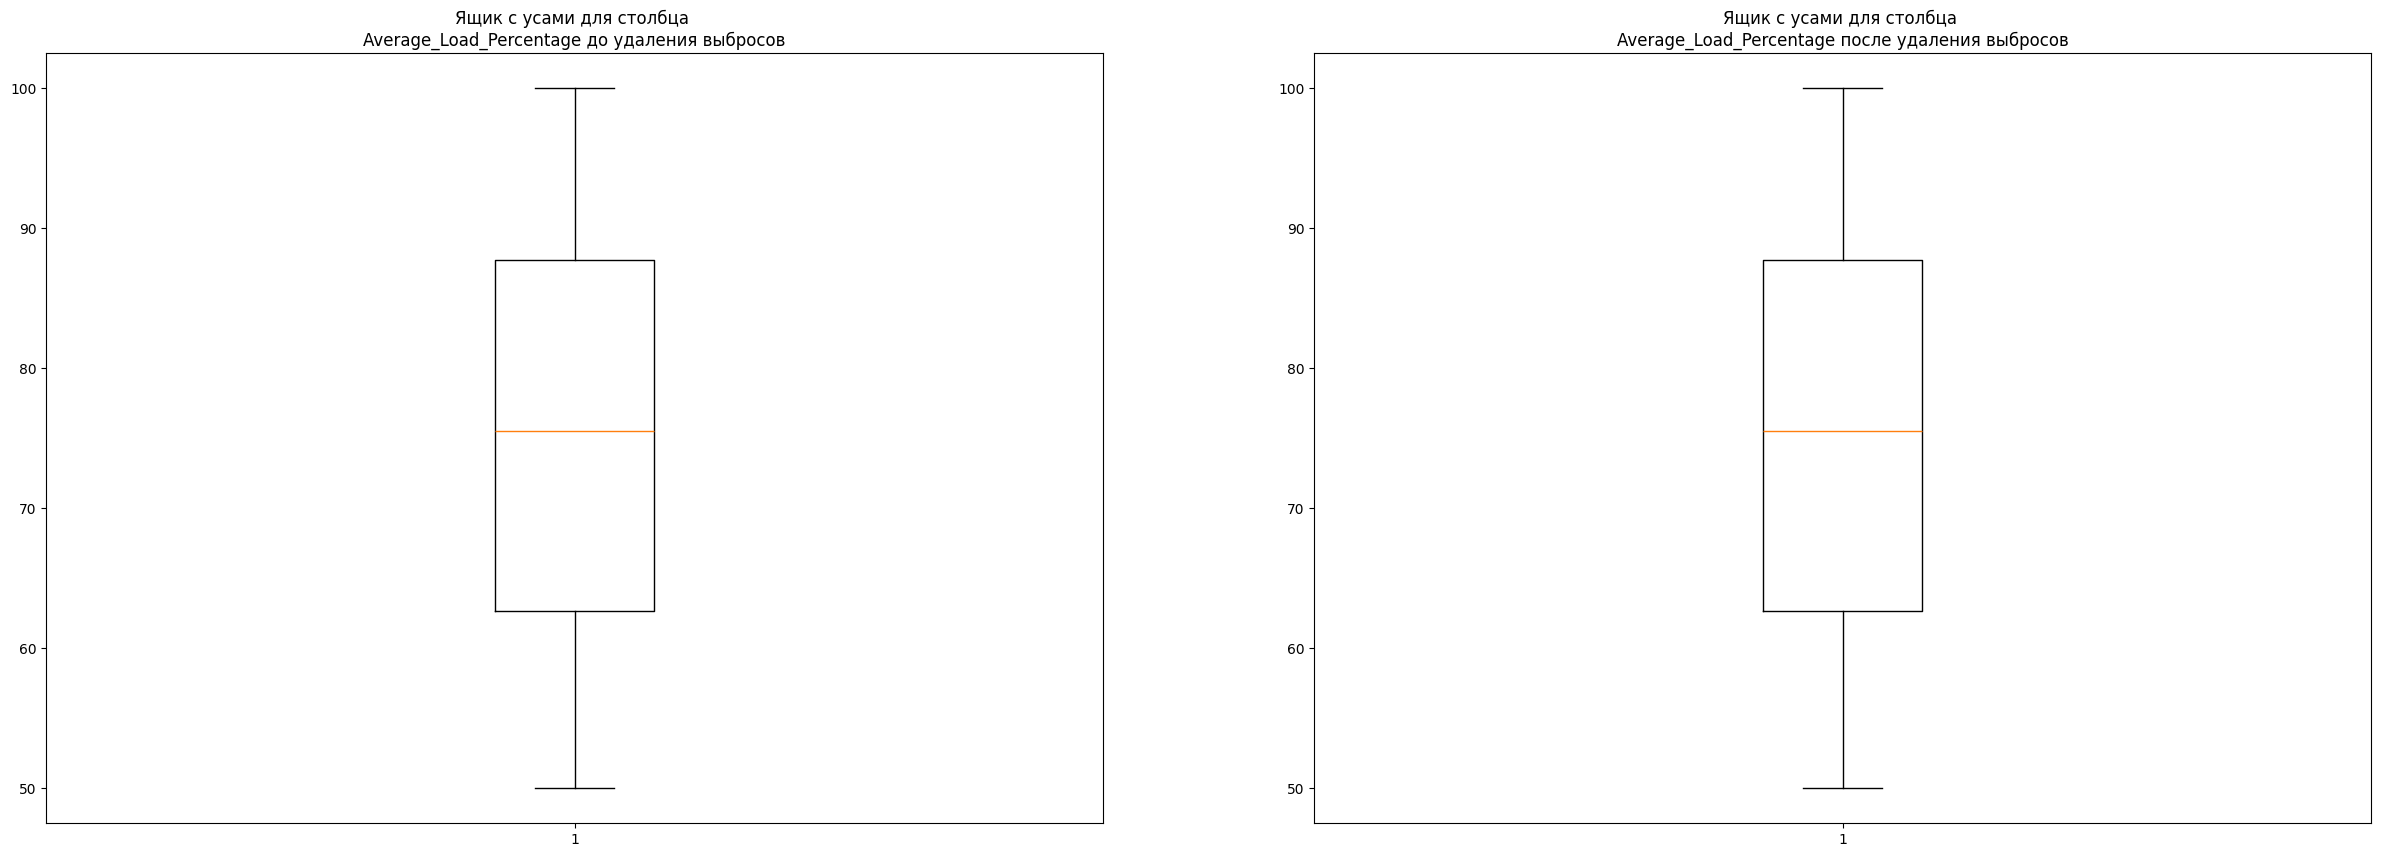

In [7]:
for column in (data.select_dtypes(exclude = "object").columns):
    delete_outliers(data, column)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh   

In [9]:
data[data.isna().any(axis = 1)]

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
8,2023-07-30,NaN,Coastal,Heavy Fuel Oil (HFO),Good,17.309362,1179.018805,429.564313,6.002358,Moderate,1953.447929,346071.519942,448682.864128,14.451820,0.977448,0.764914,8,50.247060
15,2023-09-17,Tanker,Long-haul,NaN,Good,15.087218,578.892879,1932.213132,12.998270,Rough,403.854284,424860.570956,633712.450708,68.228363,0.652674,1.308687,3,74.510221
20,2023-10-22,Container Ship,NaN,Diesel,Critical,23.803847,1120.699241,1169.478497,10.544799,Rough,1084.255595,377335.182851,371301.210298,57.593604,1.262367,1.417901,8,83.443228
21,2023-10-29,Bulk Carrier,Short-haul,Diesel,NaN,22.760363,2335.262890,1461.917538,7.980762,Calm,1100.968552,441952.077325,666766.882852,35.568562,1.050074,0.875033,6,92.187158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,2024-02-11,Fish Carrier,Transoceanic,Diesel,Fair,16.108466,2811.022082,804.239962,10.795343,NaN,1176.790300,129790.538157,703651.140757,70.353526,1.370604,1.249437,3,85.678347
2716,2024-02-18,Container Ship,Short-haul,Heavy Fuel Oil (HFO),NaN,15.261468,1672.818253,1661.187323,13.268909,Calm,1749.518478,385770.383310,762228.134071,26.175542,1.389479,0.886805,3,84.056380
2725,2024-04-21,Fish Carrier,Coastal,Steam Turbine,NaN,23.683479,1379.774999,151.442879,8.284118,Moderate,618.180656,149412.689798,271565.988148,54.733623,0.602377,0.972509,1,86.840779
2732,2024-06-09,Bulk Carrier,Short-haul,Heavy Fuel Oil (HFO),Good,13.852798,2161.282358,831.355653,14.612775,NaN,218.309002,21029.021721,374365.370930,64.325916,0.653474,0.891085,2,84.595155


In [10]:
data[["Ship_Type", "Engine_Type"]].drop_duplicates()

,Ship_Type,Engine_Type
0,Container Ship,Heavy Fuel Oil (HFO)
1,Fish Carrier,Steam Turbine
2,Container Ship,Diesel
3,Bulk Carrier,Steam Turbine
4,Fish Carrier,Diesel
5,Fish Carrier,Heavy Fuel Oil (HFO)
8,NaN,Heavy Fuel Oil (HFO)
11,Tanker,Diesel
12,Container Ship,Steam Turbine
13,Bulk Carrier,Heavy Fuel Oil (HFO)


In [11]:
data = data.drop(columns = "Date")
data = data.fillna(data.mode().iloc[0])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ship_Type                2736 non-null   object 
 1   Route_Type               2736 non-null   object 
 2   Engine_Type              2736 non-null   object 
 3   Maintenance_Status       2736 non-null   object 
 4   Speed_Over_Ground_knots  2736 non-null   float64
 5   Engine_Power_kW          2736 non-null   float64
 6   Distance_Traveled_nm     2736 non-null   float64
 7   Draft_meters             2736 non-null   float64
 8   Weather_Condition        2736 non-null   object 
 9   Cargo_Weight_tons        2736 non-null   float64
 10  Operational_Cost_USD     2736 non-null   float64
 11  Revenue_per_Voyage_USD   2736 non-null   float64
 12  Turnaround_Time_hours    2736 non-null   float64
 13  Efficiency_nm_per_kWh    2736 non-null   float64
 14  Seasonal_Impact_Score   

In [12]:
ohe = OneHotEncoder(sparse_output = False, drop = "first")
data = data.join(pd.DataFrame(ohe.fit_transform(data[["Ship_Type","Engine_Type"]]), columns = ohe.get_feature_names_out(), index = data.index)).drop(columns = ["Ship_Type", "Engine_Type"])
data.head()

,Route_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,Ship_Type_Container Ship,Ship_Type_Fish Carrier,Ship_Type_Tanker,Engine_Type_Heavy Fuel Oil (HFO),Engine_Type_Steam Turbine
0,Long-haul,Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249,1.0,0.0,0.0,1.0,0.0
1,Short-haul,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372,0.0,1.0,0.0,0.0,1.0
2,Long-haul,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244,1.0,0.0,0.0,0.0,0.0
3,Transoceanic,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698,0.0,0.0,0.0,0.0,1.0
4,Transoceanic,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581,0.0,1.0,0.0,0.0,0.0


In [13]:
print(data["Route_Type"].value_counts())
print(data["Maintenance_Status"].value_counts())
print(data["Weather_Condition"].value_counts())

Route_Type
Long-haul       822
Coastal         650
Transoceanic    638
Short-haul      626
Name: count, dtype: int64
Maintenance_Status
Good        1009
Fair         867
Critical     860
Name: count, dtype: int64
Weather_Condition
Calm        1029
Moderate     891
Rough        816
Name: count, dtype: int64


In [14]:
data["Route_Type"] = data["Route_Type"].replace({"Coastal": "Short-haul",
                                                 "Transoceanic": "Long-haul"})                                             

In [15]:
categories = [["Short-haul", "Long-haul"], ["Good", 'Fair', "Critical"], ["Calm", "Moderate", "Rough"]]
oe = OrdinalEncoder(categories = categories)
data[["Route_Type", "Maintenance_Status", "Weather_Condition"]] = oe.fit_transform(data[["Route_Type", "Maintenance_Status", "Weather_Condition"]])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Route_Type                        2736 non-null   float64
 1   Maintenance_Status                2736 non-null   float64
 2   Speed_Over_Ground_knots           2736 non-null   float64
 3   Engine_Power_kW                   2736 non-null   float64
 4   Distance_Traveled_nm              2736 non-null   float64
 5   Draft_meters                      2736 non-null   float64
 6   Weather_Condition                 2736 non-null   float64
 7   Cargo_Weight_tons                 2736 non-null   float64
 8   Operational_Cost_USD              2736 non-null   float64
 9   Revenue_per_Voyage_USD            2736 non-null   float64
 10  Turnaround_Time_hours             2736 non-null   float64
 11  Efficiency_nm_per_kWh             2736 non-null   float64
 12  Season

In [16]:
ss = StandardScaler()
data = pd.DataFrame(ss.fit_transform(data), columns = data.columns, index = data.index)
data.head()

,Route_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,Ship_Type_Container Ship,Ship_Type_Fish Carrier,Ship_Type_Tanker,Engine_Type_Heavy Fuel Oil (HFO),Engine_Type_Steam Turbine
0,0.934865,1.278580,-1.161003,0.425980,-0.009608,1.461520,0.095232,1.658525,1.623465,-0.845173,-0.900768,1.627007,1.429008,-1.507346,1.278649,1.818973,-0.559902,-0.554269,1.485767,-0.67420
1,-1.069673,-1.146512,-1.673617,0.053631,0.042355,1.642611,1.318497,-1.557798,1.620311,1.336484,1.219556,-1.259663,-0.410025,0.417824,1.287343,-0.549761,1.786027,-0.554269,-0.673053,1.48324
2,0.934865,0.066034,0.729934,-0.152125,-0.664052,-0.949214,0.095232,-1.529788,1.372949,-0.469621,0.435091,-0.741138,1.394864,1.572926,1.447458,1.818973,-0.559902,-0.554269,-0.673053,-0.67420
3,0.934865,0.066034,0.800762,-1.175035,0.159036,0.646741,0.095232,1.261758,0.044058,-1.599821,-1.096910,-0.237289,1.273042,-1.507346,-0.622127,-0.549761,-0.559902,-0.554269,-0.673053,1.48324
4,0.934865,0.066034,-0.895364,-0.931672,0.719182,-0.069985,0.095232,-1.381999,0.231250,0.570727,1.271175,1.320115,-1.458833,1.187892,0.330130,-0.549761,1.786027,-0.554269,-0.673053,-0.67420


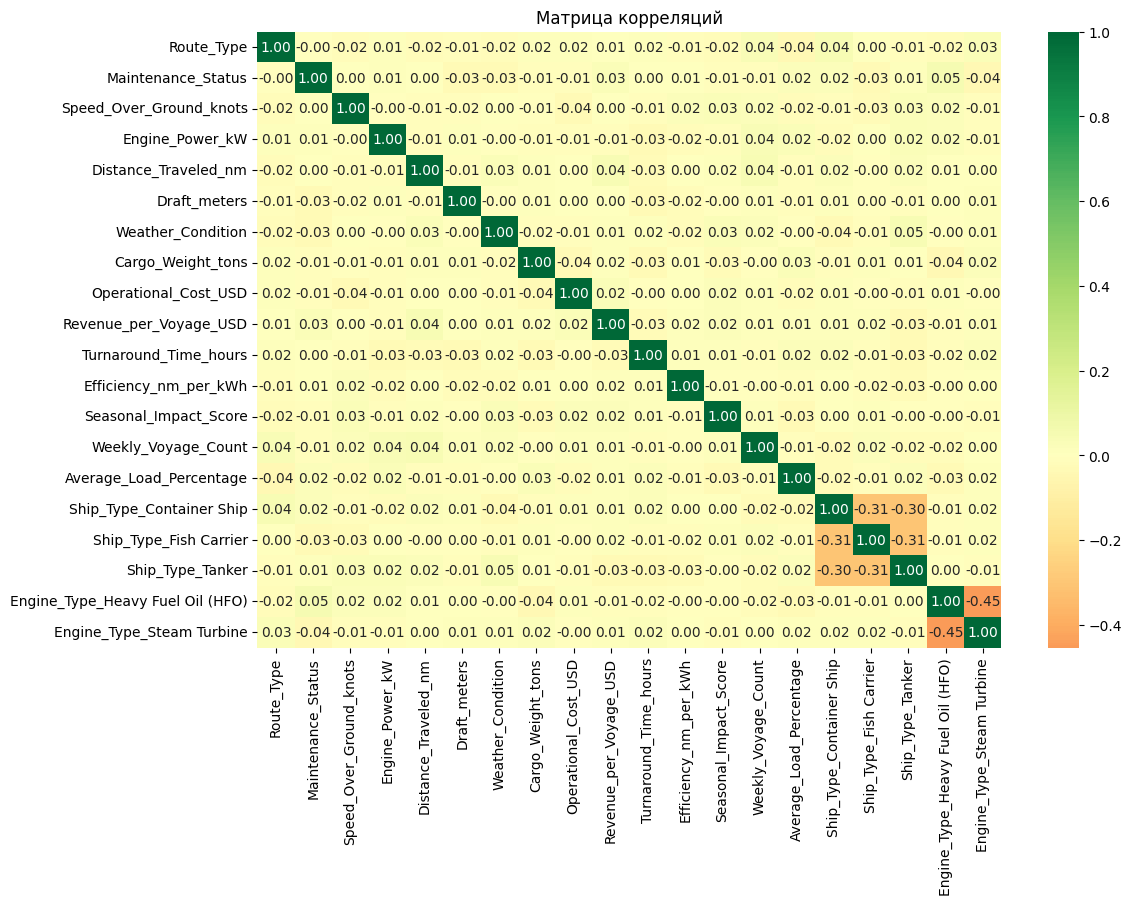

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap = "RdYlGn", fmt=".2f", center = 0)
plt.title('Матрица корреляций')
plt.show()

[-3318.65666317 -2941.26834921 -1768.72595076 -1385.39698192
  -805.65201861  -788.87901833  -569.11328853  -703.96102705
  -502.53592888]


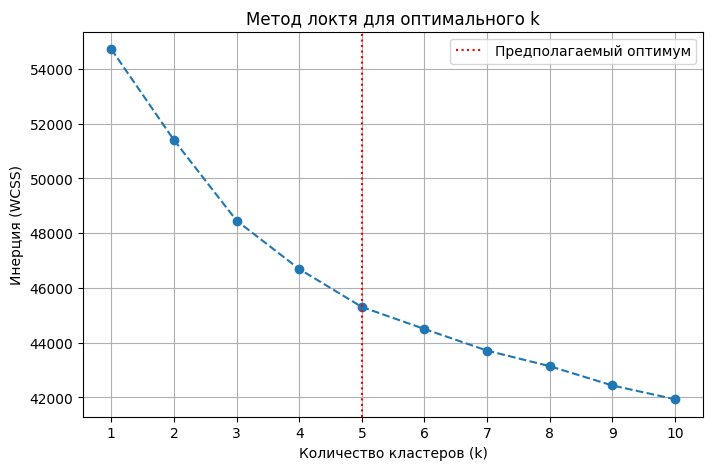

In [18]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    inertia.append(kmeans.inertia_) 

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (WCSS)')
plt.title('Метод локтя для оптимального k')
plt.xticks(k_range)
plt.grid(True)

print(np.diff(inertia))

plt.axvline(x=5, color='red', linestyle=':', label='Предполагаемый оптимум')
plt.legend()
plt.show()


k = 2, Silhouette Score = 0.0656
k = 3, Silhouette Score = 0.0828
k = 4, Silhouette Score = 0.0714
k = 5, Silhouette Score = 0.0647
k = 6, Silhouette Score = 0.0578
k = 7, Silhouette Score = 0.0639
k = 8, Silhouette Score = 0.0602
k = 9, Silhouette Score = 0.0620
k = 10, Silhouette Score = 0.0645
k = 11, Silhouette Score = 0.0578
k = 12, Silhouette Score = 0.0637
k = 13, Silhouette Score = 0.0624
k = 14, Silhouette Score = 0.0605
k = 15, Silhouette Score = 0.0576
k = 16, Silhouette Score = 0.0557
k = 17, Silhouette Score = 0.0571
k = 18, Silhouette Score = 0.0514
k = 19, Silhouette Score = 0.0527


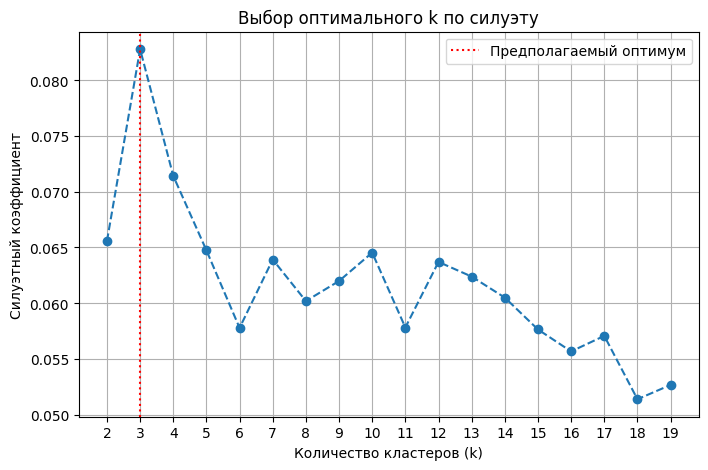

In [19]:
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data)
    score = silhouette_score(data, cluster_labels)
    silhouette_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Выбор оптимального k по силуэту')
plt.xticks(k_range)
plt.grid(True)

plt.axvline(x=3, color='red', linestyle=':', label='Предполагаемый оптимум')
plt.legend()
plt.show()

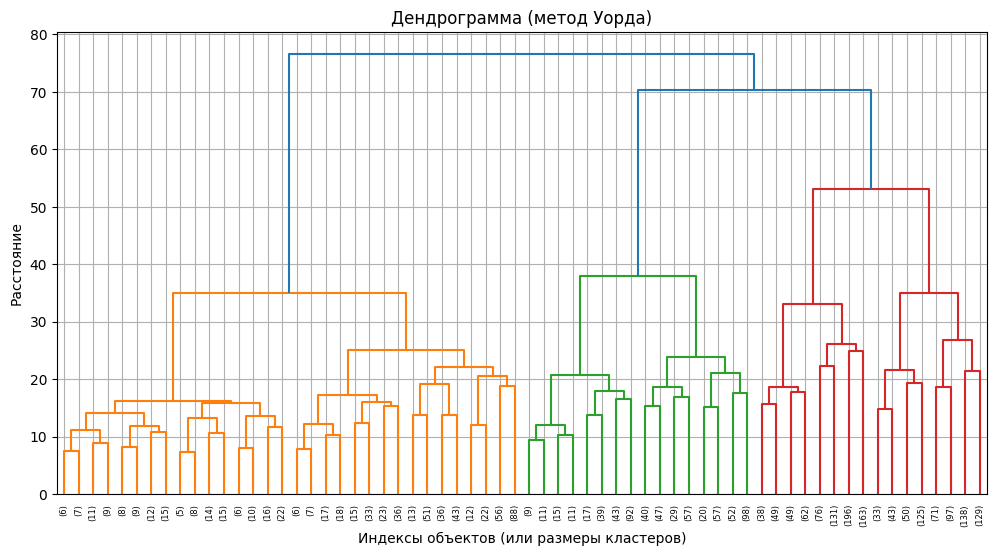

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(data, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title('Дендрограмма (метод Уорда)')
plt.xlabel('Индексы объектов (или размеры кластеров)')
plt.ylabel('Расстояние')
plt.grid(True)
plt.show()


In [21]:
scores = pd.DataFrame(np.zeros((3, 3)), columns = ["K-means", "Agglomerative", "DBSCAN"], index = ["Silhouette", "Calinski Harabasz", "Davies Bouldin"])

In [22]:
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
y_kmeans = kmeans.fit_predict(data)
y_agglomerative = fcluster(Z, t=3, criterion='maxclust')
db = DBSCAN(eps = 3.55, min_samples=5)
y_dbscan = db.fit_predict(data)
set(y_dbscan)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2)}

In [23]:
for i, result in enumerate([y_kmeans, y_agglomerative, y_dbscan]):
    scores.iloc[0, i] = silhouette_score(data, result)
    scores.iloc[1, i] = calinski_harabasz_score(data, result)
    scores.iloc[2, i] = davies_bouldin_score(data, result)


In [24]:
scores

,K-means,Agglomerative,DBSCAN
Silhouette,0.082777,0.068508,-0.052247
Calinski Harabasz,176.520311,149.645000,2.929383
Davies Bouldin,3.224553,3.538259,10.568825


In [25]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(data)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Объяснённая дисперсия каждой компоненты:", explained_variance_ratio)
print()
print("Накопленная объяснённая:", cumulative_variance)

Объяснённая дисперсия каждой компоненты: [0.07408477 0.06688855 0.06603196 0.05566489 0.05458163 0.05382932
 0.05225714 0.05200433 0.0517583  0.05068149 0.04944445 0.04849307
 0.04784315 0.0477039  0.04716466 0.04583691 0.045037   0.04445023
 0.02717606 0.01906818]

Накопленная объяснённая: [0.07408477 0.14097333 0.20700529 0.26267018 0.31725181 0.37108113
 0.42333827 0.4753426  0.5271009  0.57778239 0.62722684 0.67571991
 0.72356306 0.77126696 0.81843162 0.86426853 0.90930553 0.95375576
 0.98093182 1.        ]


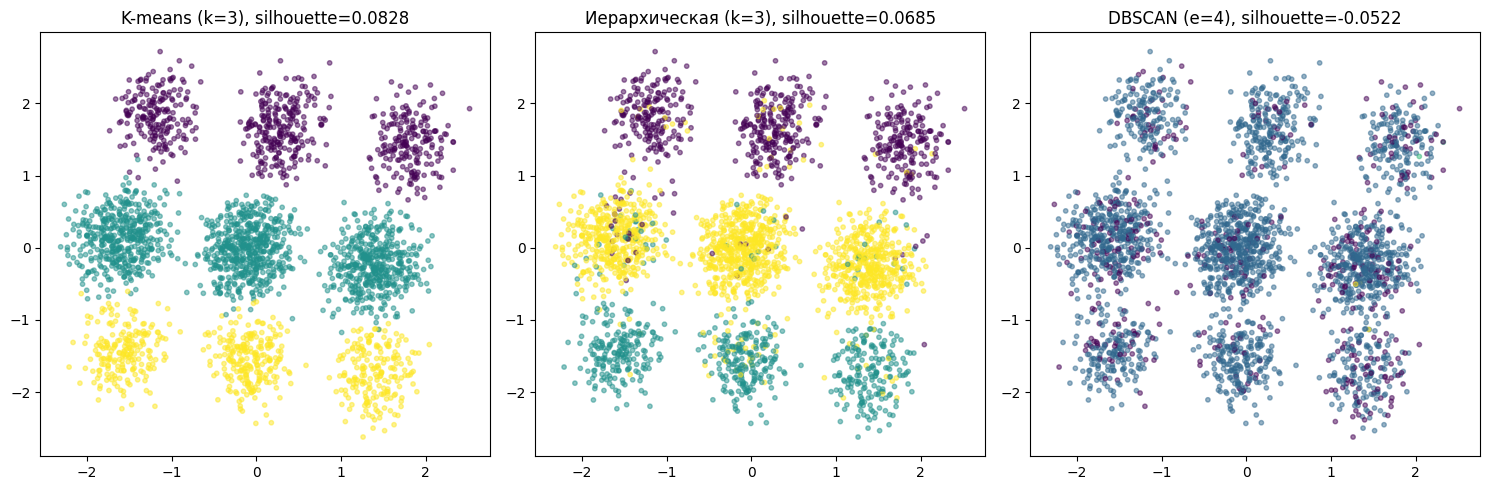

PCA объясняет 0.141 дисперсии в 2D


In [26]:
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=y_kmeans, cmap='viridis', alpha=0.5, s=10)
plt.title(f'K-means (k=3), silhouette={silhouette_score(data, y_kmeans):.4f}')

plt.subplot(1, 3, 2)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=y_agglomerative, cmap='viridis', alpha=0.5, s=10)
plt.title(f'Иерархическая (k=3), silhouette={silhouette_score(data, y_agglomerative):.4f}')

plt.subplot(1, 3, 3)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=y_dbscan, cmap='viridis', alpha=0.5, s=10)
plt.title(f'DBSCAN (e=4), silhouette={silhouette_score(data, y_dbscan):.4f}')

plt.tight_layout()
plt.show()

print(f"PCA объясняет {sum(pca.explained_variance_ratio_):.3f} дисперсии в 2D")

In [27]:
new_scores = pd.DataFrame(np.zeros((3, 3)), columns = ["K-means", "Agglomerative", "DBSCAN"], index = ["Silhouette", "Calinski Harabasz", "Davies Bouldin"])

kmeans = KMeans(n_clusters = 9, random_state = 42, n_init = 10)
y_kmeans = kmeans.fit_predict(data)
y_agglomerative = fcluster(Z, t=9, criterion='maxclust')
db = DBSCAN(eps = 3.47, min_samples=5)
y_dbscan = db.fit_predict(data)
set(y_dbscan)

for i, result in enumerate([y_kmeans, y_agglomerative, y_dbscan]):
    new_scores.iloc[0, i] = silhouette_score(data, result)
    new_scores.iloc[1, i] = calinski_harabasz_score(data, result)
    new_scores.iloc[2, i] = davies_bouldin_score(data, result)
    
new_scores

,K-means,Agglomerative,DBSCAN
Silhouette,0.061996,0.031925,-0.141299
Calinski Harabasz,98.649191,73.128445,3.078768
Davies Bouldin,3.352736,3.983119,5.944435


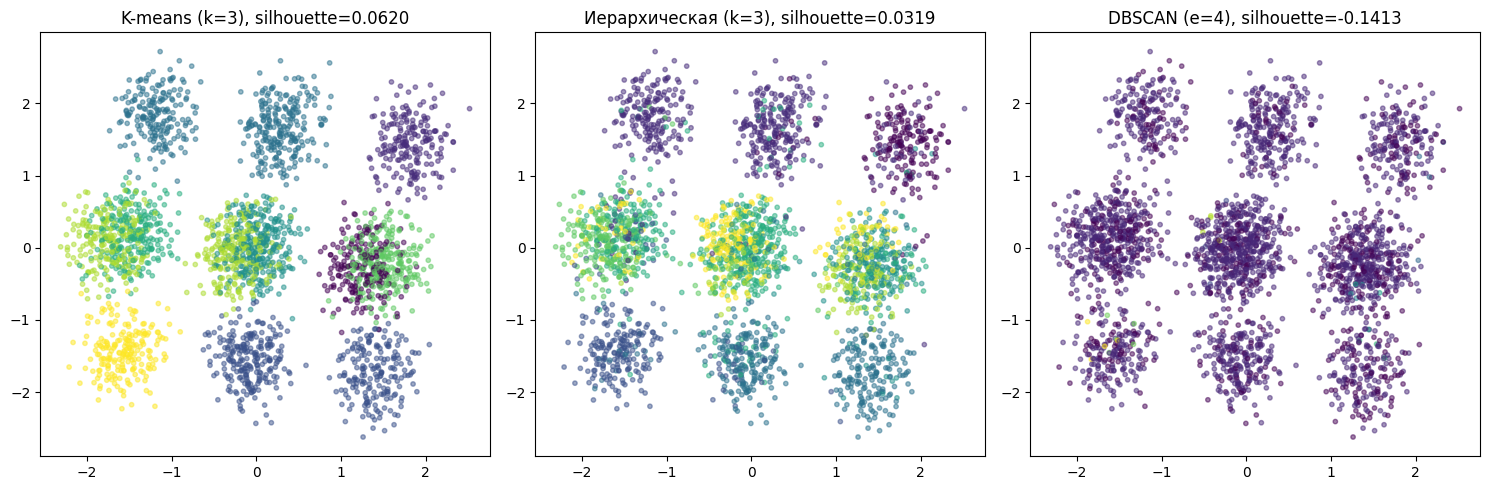

PCA объясняет 0.141 дисперсии в 2D


In [28]:
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=y_kmeans, cmap='viridis', alpha=0.5, s=10)
plt.title(f'K-means (k=3), silhouette={silhouette_score(data, y_kmeans):.4f}')

plt.subplot(1, 3, 2)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=y_agglomerative, cmap='viridis', alpha=0.5, s=10)
plt.title(f'Иерархическая (k=3), silhouette={silhouette_score(data, y_agglomerative):.4f}')

plt.subplot(1, 3, 3)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=y_dbscan, cmap='viridis', alpha=0.5, s=10)
plt.title(f'DBSCAN (e=4), silhouette={silhouette_score(data, y_dbscan):.4f}')

plt.tight_layout()
plt.show()

print(f"PCA объясняет {sum(pca.explained_variance_ratio_):.3f} дисперсии в 2D")

In [29]:
scores

,K-means,Agglomerative,DBSCAN
Silhouette,0.082777,0.068508,-0.052247
Calinski Harabasz,176.520311,149.645000,2.929383
Davies Bouldin,3.224553,3.538259,10.568825


In [30]:
new_scores

,K-means,Agglomerative,DBSCAN
Silhouette,0.061996,0.031925,-0.141299
Calinski Harabasz,98.649191,73.128445,3.078768
Davies Bouldin,3.352736,3.983119,5.944435
